## 1. Environment Setup and Dependencies

# Hierarchical Text Classification for Research Papers
## Fine-tuning with 7-Level Taxonomy

This notebook implements fine-tuning of a language model for hierarchical text classification with:
- **7-level taxonomy** with automatic padding for shorter paths
- **Checkpoint-based training** for session recovery on limited GPU
- **Comprehensive evaluation** with hierarchical metrics
- **Visualization** of training progress and results

**Key Features:**
- Efficient training on the H100 GPU (DistilBERT/SciBERT)
- Automatic session recovery from checkpoints
- Multi-level classification evaluation
- Taxonomy path validation

In [1]:
!pip uninstall -y scipy
!pip install scipy==1.11.4

Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4
  Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (36.4 MB)


In [2]:
# Install required packages
!pip install torch transformers datasets accelerate scikit-learn tqdm pandas numpy

In [3]:
pip install peft


Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
    set_seed
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

# Set random seeds for reproducibility
set_seed(42)


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch version: 2.9.1+cu128
CUDA available: True
GPU: NVIDIA H100 NVL MIG 1g.24gb
GPU Memory: 21.6 GB


# data Path

In [2]:

TAXONOMY_PATH = "Taxonomy_building/preprocessed_taxonomy.json"
TRAIN_DATA_DIR  = "final_data/final_final_annotation_train_data_fast_unzipped/final_final_annotation_train_data_fast"
TEST_DATA_DIR  = "final_data/final_final_annotation_test_data_fast_unzipped/final_final_annotation_test_data_fast"


## 3. Configuration 

In [3]:
CONFIG = {
    # Model configuration
    'model_name': 'allenai/scibert_scivocab_uncased',  # Faster and lighter than SciBERT
    'max_length': 512,                    # Maximum sequence length
    'batch_size': 8,                      # Batch size (reduce if OOM)
    'gradient_accumulation_steps': 4,     # Effective batch size
    'learning_rate': 1e-4,
    'num_epochs': 5,
    'warmup_ratio': 0.1,
    'max_grad_norm': 1.0,

    # Training settings
    'save_steps': 500,
    'eval_steps': 500,
    'logging_steps': 100,
    'early_stopping_patience': 3,

    # Hierarchical classification
    'num_levels': 7,
     # Paths
    'taxonomy_path': TAXONOMY_PATH,
    'train_data': TRAIN_DATA_DIR,
    'test_data': TEST_DATA_DIR,
    'checkpoint_dir': './checkpoints',
    'output_dir': './outputs',
}


## Verification

This section verifies configuration settings, creates required directories, and checks whether all required data paths exist.

In [4]:
#verification
os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['output_dir'], exist_ok=True)

print("Configuration loaded!")
print(f"Model: {CONFIG['model_name']}")
print(f"Effective batch size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']}")

print("\nVerifying data paths:")
print(f"  Taxonomy: {CONFIG['taxonomy_path']}")
print(f"    Exists: {os.path.exists(CONFIG['taxonomy_path'])}")
print(f"  Training data: {CONFIG['train_data']}")
print(f"    Exists: {os.path.exists(CONFIG['train_data'])}")
print(f"  Test data: {CONFIG['test_data']}")
print(f"    Exists: {os.path.exists(CONFIG['test_data'])}")

if not all([
    os.path.exists(CONFIG['taxonomy_path']),
    os.path.exists(CONFIG['train_data']),
    os.path.exists(CONFIG['test_data'])
]):
    print("\n⚠️ WARNING: Some data paths don't exist!")


Configuration loaded!
Model: allenai/scibert_scivocab_uncased
Effective batch size: 32

Verifying data paths:
  Taxonomy: Taxonomy_building/preprocessed_taxonomy.json
    Exists: True
  Training data: final_data/final_final_annotation_train_data_fast_unzipped/final_final_annotation_train_data_fast
    Exists: True
  Test data: final_data/final_final_annotation_test_data_fast_unzipped/final_final_annotation_test_data_fast
    Exists: True


## Taxonomy Path Extraction and Padding

This section loads a taxonomy file, recursively extracts all hierarchical paths, and pads each path to a fixed depth of **7 levels** to ensure consistency.


In [5]:
def extract_all_paths(taxonomy_dict, current_path=None):
    """
    Recursively extract all paths from the taxonomy.
    Returns a list of tuples representing hierarchical paths.
    """
    if current_path is None:
        current_path = []

    all_paths = []

    if isinstance(taxonomy_dict, dict):
        for key, value in taxonomy_dict.items():
            new_path = current_path + [key]
            if isinstance(value, dict):
                all_paths.extend(extract_all_paths(value, new_path))
            elif isinstance(value, list):
                for item in value:
                    all_paths.append(tuple(new_path + [item]))
            else:
                all_paths.append(tuple(new_path))

    elif isinstance(taxonomy_dict, list):
        for item in taxonomy_dict:
            all_paths.append(tuple(current_path + [item]))

    return all_paths

def pad_path_to_7_levels(path):
    """
    Pad a path to exactly 7 levels by repeating the last element.
    Example: (A, B, C) -> (A, B, C, C, C, C, C)
    """
    path_list = list(path)
    while len(path_list) < 7:
        path_list.append(path_list[-1])
    return tuple(path_list[:7])  # Ensure exactly 7 levels

# Load taxonomy
print("Loading taxonomy...")
with open(CONFIG['taxonomy_path'], 'r', encoding='utf-8') as f:
    taxonomy_data = json.load(f)

# Extract all paths
all_paths = extract_all_paths(taxonomy_data['taxonomy'])
print(f"Total paths in taxonomy: {len(all_paths)}")

# Show example paths before padding
print("\nExample paths (before padding):")
for path in all_paths[:5]:
    print(f"  Length {len(path)}: {' > '.join(path)}")

# Pad all paths to 7 levels
padded_paths = [pad_path_to_7_levels(path) for path in all_paths]

# Show example paths after padding
print("\nExample paths (after padding to 7 levels):")
for i, path in enumerate(padded_paths[:5]):
    print(f"  {' > '.join(path)}")

# Create mapping of valid paths
valid_paths_set = set(padded_paths)
print(f"\nTotal unique 7-level paths: {len(valid_paths_set)}")

Loading taxonomy...
Total paths in taxonomy: 1449

Example paths (before padding):
  Length 5: Natural Science > Mathematics > Pure Mathematics > Algebra > Abstract Algebra
  Length 5: Natural Science > Mathematics > Pure Mathematics > Algebra > Linear Algebra
  Length 5: Natural Science > Mathematics > Pure Mathematics > Algebra > Commutative Algebra
  Length 5: Natural Science > Mathematics > Pure Mathematics > Algebra > Homological Algebra
  Length 5: Natural Science > Mathematics > Pure Mathematics > Algebra > Representation Theory

Example paths (after padding to 7 levels):
  Natural Science > Mathematics > Pure Mathematics > Algebra > Abstract Algebra > Abstract Algebra > Abstract Algebra
  Natural Science > Mathematics > Pure Mathematics > Algebra > Linear Algebra > Linear Algebra > Linear Algebra
  Natural Science > Mathematics > Pure Mathematics > Algebra > Commutative Algebra > Commutative Algebra > Commutative Algebra
  Natural Science > Mathematics > Pure Mathematics > Alge

## Label Encoding for Taxonomy Levels

This section creates **label encoders for each of the 7 taxonomy levels**.  
Each encoder maps string labels to numeric IDs and back, enabling efficient model training.

In [6]:
# Create label encoders for each of the 7 levels
label_encoders = []
for level in range(7):
    # Get all unique labels at this level
    labels_at_level = set([path[level] for path in padded_paths])
    labels_sorted = sorted(list(labels_at_level))
    
    # Create mappings
    label_to_id = {label: idx for idx, label in enumerate(labels_sorted)}
    id_to_label = {idx: label for label, idx in label_to_id.items()}
    
    label_encoders.append({
        'label_to_id': label_to_id,
        'id_to_label': id_to_label,
        'num_labels': len(labels_sorted)
    })
    
    print(f"Level {level}: {len(labels_sorted)} unique labels")

# Display example encodings
print("\nExample label encodings for Level 0:")
for label, idx in list(label_encoders[0]['label_to_id'].items())[:10]:
    print(f"  {label} -> {idx}")

Level 0: 7 unique labels
Level 1: 58 unique labels
Level 2: 275 unique labels
Level 3: 871 unique labels
Level 4: 1280 unique labels
Level 5: 1383 unique labels
Level 6: 1393 unique labels

Example label encodings for Level 0:
  Agricultural Science -> 0
  Engineering and Technology -> 1
  Humanity and Art -> 2
  Interdisciplinary Field -> 3
  Medical and Health Science -> 4
  Natural Science -> 5
  Social Science -> 6


## Loading JSON Data

This section defines a function to **load all JSON files from a directory** and aggregate the articles for training and testing.  
It handles different JSON structures and prints progress using `tqdm`.


In [7]:
from typing import List, Dict, Any
from pathlib import Path
from tqdm import tqdm
import json

def load_json_files(data_dir: str) -> List[Dict[str, Any]]:
    """Load all JSON files from directory."""
    all_articles = []
    json_files = list(Path(data_dir).glob("*.json"))
    
    print(f"Found {len(json_files)} JSON files")
    
    for json_file in tqdm(json_files, desc="Loading files"):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
                if isinstance(data, list):
                    articles = data
                elif isinstance(data, dict):
                    articles = data.get('articles', [data])
                else:
                    continue
                
                valid_articles = [a for a in articles if isinstance(a, dict)]
                all_articles.extend(valid_articles)
                
        except Exception as e:
            print(f"Error loading {json_file.name}: {e}")
            continue
    
    print(f"Total articles loaded: {len(all_articles)}")
    return all_articles

# Load data
print("="*60)
print("LOADING TRAINING DATA")
print("="*60)
train_articles = load_json_files(TRAIN_DATA_DIR)

print("\n" + "="*60)
print("LOADING TEST DATA")
print("="*60)
test_articles = load_json_files(TEST_DATA_DIR)

LOADING TRAINING DATA
Found 4107 JSON files


Loading files: 100%|██████████| 4107/4107 [00:57<00:00, 71.11it/s] 


Total articles loaded: 1012683

LOADING TEST DATA
Found 4009 JSON files


Loading files: 100%|██████████| 4009/4009 [00:09<00:00, 441.89it/s] 

Total articles loaded: 120041


## Preprocessing Data

This section **cleans and normalizes text**, parses classification paths, and pads labels to a fixed depth for model input.

In [8]:
#preprocessing
def clean_text(text):
    """Clean and normalize text."""
    if not text:
        return ""
    
    # Remove HTML tags if any
    text = re.sub(r'<[^>]+>', '', str(text))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

def parse_classification_path(path_string):
    """
    Parse classification path string into a list of labels.
    Example: "Natural Science > Mathematics > Algebra" -> ["Natural Science", "Mathematics", "Algebra"]
    """
    if not path_string:
        return None
    
    # Split by '>' and clean each part
    labels = [label.strip() for label in path_string.split('>')]
    
    # Remove empty labels
    labels = [label for label in labels if label]
    
    return labels if labels else None

def preprocess_sample(sample):
    """Preprocess a single data sample."""
    processed = {}
    
    # Extract title and abstract
    title = clean_text(sample.get('title', ''))
    abstract = clean_text(sample.get('abstract', ''))
    
    # Combine title and abstract
    processed['text'] = f"{title} [SEP] {abstract}"
    
    # Parse classification path
    classification_path = sample.get('classification_path', '')
    labels = parse_classification_path(classification_path)
    
    if not labels:
        return None
    
    # Pad labels to 7 levels
    padded_labels = labels.copy()
    while len(padded_labels) < 7:
        padded_labels.append(padded_labels[-1])
    padded_labels = padded_labels[:7]
    
    processed['labels'] = padded_labels
    processed['original_path'] = classification_path
    
    return processed

# Preprocess training data
print("Preprocessing training data...")
train_processed = []
for sample in train_articles:
    processed = preprocess_sample(sample)
    if processed:
        train_processed.append(processed)

print(f"Successfully preprocessed {len(train_processed)}/{len(train_articles)} training samples")

# Preprocess test data
print("\nPreprocessing test data...")
test_processed = []
for sample in test_articles:
    processed = preprocess_sample(sample)
    if processed:
        test_processed.append(processed)

print(f"Successfully preprocessed {len(test_processed)}/{len(test_articles)} test samples")

# Display example
print("\nExample preprocessed sample:")
example = train_processed[0]
print(f"Text (first 200 chars): {example['text'][:200]}...")
print(f"Labels: {' > '.join(example['labels'])}")

Preprocessing training data...
Successfully preprocessed 1012683/1012683 training samples

Preprocessing test data...
Successfully preprocessed 120041/120041 test samples

Example preprocessed sample:
Text (first 200 chars): pd gait: contactless and privacy preserving gait measurement of parkinson's disease patients using acoustic signals [SEP] abstract in this article, we propose a mobile edge computing (mec) related sys...
Labels: Natural Science > Computer and Information Science > Computer Security and Privacy > Privacy Technology > Differential Privacy > Differential Privacy > Differential Privacy


In [ ]:
pip install -U transformers


## Tokenization and Dataset Setup

This section initializes the tokenizer, defines a **custom dataset** for hierarchical classification, and prepares **PyTorch dataloaders**.

In [9]:
# Initialize tokenizer
print(f"Loading tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(
    CONFIG['model_name'],
    use_fast=False,       # force slow tokenizer
    trust_remote_code=True  # allow custom tokenizer code if needed
)
class HierarchicalDataset(Dataset):
    """Dataset for hierarchical text classification."""
    
    def __init__(self, data, tokenizer, label_encoders, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.label_encoders = label_encoders
        self.max_length = max_length
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Tokenize text
        encoding = self.tokenizer(
            item['text'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Convert labels to ids for each level
        label_ids = []
        for level, label in enumerate(item['labels']):
            label_id = self.label_encoders[level]['label_to_id'].get(label, 0)
            label_ids.append(label_id)
        
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label_ids, dtype=torch.long)
        }

# Create datasets
train_dataset = HierarchicalDataset(
    train_processed,
    tokenizer,
    label_encoders,
    CONFIG['max_length']
)

test_dataset = HierarchicalDataset(
    test_processed,
    tokenizer,
    label_encoders,
    CONFIG['max_length']
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0  # Set to 0 for Kaggle
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0
)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")

Loading tokenizer: allenai/scibert_scivocab_uncased
Training batches: 126586
Test batches: 15006

Sample batch shapes:
  input_ids: torch.Size([8, 512])
  attention_mask: torch.Size([8, 512])
  labels: torch.Size([8, 7])


## Hierarchical Text Classifier with LoRA

This section defines a **hierarchical text classifier** with 7 classification heads,  
using **LoRA (Low-Rank Adaptation)** for parameter-efficient fine-tuning of the transformer backbone.

In [10]:
import torch
import torch.nn as nn
from transformers import AutoModel
from peft import get_peft_model, LoraConfig, TaskType

class HierarchicalClassifier(nn.Module):
    """
    Hierarchical text classifier with 7 classification heads.
    Uses LoRA (Low-Rank Adaptation) for parameter-efficient fine-tuning.
    """
    def __init__(self, model_name, label_encoders, use_lora=True):
        super(HierarchicalClassifier, self).__init__()
        
        # Load pretrained transformer
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        
        # Apply LoRA for parameter-efficient fine-tuning
        if use_lora:
            lora_config = LoraConfig(
                r=8,                          # Rank of LoRA matrices
                lora_alpha=16,                # Scaling factor
                target_modules=["query", "value"],  # Target modules in attention
                lora_dropout=0.1,
                bias="none",
                task_type=TaskType.FEATURE_EXTRACTION
            )
            self.backbone = get_peft_model(self.backbone, lora_config)
            print("LoRA applied to backbone:")
            self.backbone.print_trainable_parameters()
        
        # Classification heads for each of the 7 levels
        self.classifiers = nn.ModuleList([
            nn.Linear(hidden_size, encoder['num_labels'])
            for encoder in label_encoders
        ])
        
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, input_ids, attention_mask):
        # Transformer outputs
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use [CLS] token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        
        # Get logits for each level
        logits = [classifier(pooled_output) for classifier in self.classifiers]
        return logits


# Model Initialization and Parameter Summary

This section initializes the **HierarchicalClassifier** with LoRA, moves it to the appropriate device (GPU if available), and prints the total and trainable parameters.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize model
print("Initializing model with LoRA...")
model = HierarchicalClassifier(CONFIG['model_name'], label_encoders, use_lora=True)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Initializing model with LoRA...
LoRA applied to backbone:
trainable params: 294,912 || all params: 110,213,376 || trainable%: 0.2676
Total parameters: 114,263,699
Trainable parameters: 4,345,235


## Training Setup and Checkpointing

This section defines the **loss function, optimizer, learning rate scheduler**, and utilities for **saving/loading checkpoints**

In [12]:
# Loss function - CrossEntropy for each level
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.01)

# Learning rate scheduler
num_training_steps = len(train_loader) * CONFIG['num_epochs'] // CONFIG['gradient_accumulation_steps']
num_warmup_steps = int(num_training_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Training steps: {num_training_steps}")
print(f"Warmup steps: {num_warmup_steps}")

# Checkpoint utilities
def save_checkpoint(model, optimizer, scheduler, epoch, step, best_f1, checkpoint_dir):
    """Save model checkpoint."""
    checkpoint = {
        'epoch': epoch,
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_f1': best_f1,
        'label_encoders': label_encoders
    }
    
    checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch{epoch}_step{step}.pt')
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")
    
    return checkpoint_path

def load_latest_checkpoint(checkpoint_dir, model, optimizer, scheduler):
    """Load the latest checkpoint if it exists."""
    checkpoints = list(Path(checkpoint_dir).glob('checkpoint_*.pt'))
    
    if not checkpoints:
        print("No checkpoint found. Starting from scratch.")
        return 0, 0, 0.0
    
    # Get the latest checkpoint
    latest_checkpoint = max(checkpoints, key=os.path.getctime)
    print(f"Loading checkpoint: {latest_checkpoint}")
    
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    print(f"Resumed from epoch {checkpoint['epoch']}, step {checkpoint['step']}")
    
    return checkpoint['epoch'], checkpoint['step'], checkpoint['best_f1']

# Try to load existing checkpoint
start_epoch, start_step, best_f1 = load_latest_checkpoint(
    CONFIG['checkpoint_dir'], model, optimizer, scheduler
)

print(f"\nTraining will start from:")
print(f"  Epoch: {start_epoch}")
print(f"  Step: {start_step}")
print(f"  Best F1: {best_f1:.4f}")

Training steps: 158232
Warmup steps: 15823
Loading checkpoint: checkpoints/checkpoint_epoch2_step0.pt
Resumed from epoch 2, step 0

Training will start from:
  Epoch: 2
  Step: 0
  Best F1: 0.0000


## Training Setup and Checkpointing

This section defines the **loss function, optimizer, learning rate scheduler**, and utilities for **saving/loading checkpoints**to resume training in case it was stopped

In [13]:
from tqdm.auto import tqdm

# Training history
history = {
    'train_loss': [],
    'eval_f1': [],
    'level_f1': {i: [] for i in range(7)}
}

def train_epoch(model, train_loader, optimizer, scheduler, epoch):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")
    
    optimizer.zero_grad()
    
    for step, batch in enumerate(progress_bar):
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)  # Shape: [batch_size, 7]
        
        # Forward pass
        logits = model(input_ids, attention_mask)
        
        # Calculate loss for each level
        loss = 0
        for level in range(7):
            level_loss = criterion(logits[level], labels[:, level])
            loss += level_loss
        
        # Average loss across levels
        loss = loss / 7
        
        # Backward pass with gradient accumulation
        loss = loss / CONFIG['gradient_accumulation_steps']
        loss.backward()
        
        if (step + 1) % CONFIG['gradient_accumulation_steps'] == 0:
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['max_grad_norm'])
            
            # Optimizer step
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * CONFIG['gradient_accumulation_steps']
        progress_bar.set_postfix({'loss': loss.item() * CONFIG['gradient_accumulation_steps']})
    
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(model, test_loader):
    """Evaluate model on test set."""
    model.eval()
    
    all_predictions = {i: [] for i in range(7)}
    all_labels = {i: [] for i in range(7)}
    
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']
        
        # Get predictions
        logits = model(input_ids, attention_mask)
        
        for level in range(7):
            preds = torch.argmax(logits[level], dim=-1).cpu().numpy()
            all_predictions[level].extend(preds)
            all_labels[level].extend(labels[:, level].numpy())
    
    # Calculate F1 for each level
    f1_scores = {}
    for level in range(7):
        f1 = f1_score(all_labels[level], all_predictions[level], average='macro', zero_division=0)
        f1_scores[level] = f1
    
    # Average F1 across all levels
    avg_f1 = np.mean(list(f1_scores.values()))
    
    return avg_f1, f1_scores, all_predictions, all_labels

print("Starting training...")
print("="*50)

Starting training...


## Main Training Loop

This section runs the **training and evaluation loop**, implements **early stopping**, and saves **checkpoints and the best model**

In [14]:
# Main training loop
global_step = start_step
patience_counter = 0

for epoch in range(start_epoch, CONFIG['num_epochs']):
    print(f"\nEpoch {epoch + 1}/{CONFIG['num_epochs']}")
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, epoch + 1)
    history['train_loss'].append(train_loss)
    print(f"Average training loss: {train_loss:.4f}")
    
    # Evaluate
    print("\nEvaluating on test set...")
    avg_f1, f1_scores, predictions, true_labels = evaluate(model, test_loader)
    history['eval_f1'].append(avg_f1)
    
    for level, f1 in f1_scores.items():
        history['level_f1'][level].append(f1)
    
    print(f"Average F1 Score: {avg_f1:.4f}")
    print("F1 Scores by Level:")
    for level, f1 in f1_scores.items():
        print(f"  Level {level}: {f1:.4f}")
    
    # Save checkpoint
    checkpoint_path = save_checkpoint(
        model, optimizer, scheduler, epoch + 1, global_step, best_f1, CONFIG['checkpoint_dir']
    )
    
    # Check for improvement
    if avg_f1 > best_f1:
        best_f1 = avg_f1
        patience_counter = 0
        
        # Save best model
        best_model_path = os.path.join(CONFIG['output_dir'], 'best_model.pt')
        torch.save({
            'model_state_dict': model.state_dict(),
            'label_encoders': label_encoders,
            'f1_score': best_f1
        }, best_model_path)
        print(f"New best F1: {best_f1:.4f}! Model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{CONFIG['early_stopping_patience']}")
        
        if patience_counter >= CONFIG['early_stopping_patience']:
            print("\nEarly stopping triggered!")
            break
    
    global_step += len(train_loader)

print("\n" + "="*50)
print("Training completed!")
print(f"Best F1 Score: {best_f1:.4f}")


Epoch 3/5


Epoch 3:   0%|          | 0/126586 [00:00<?, ?it/s]

Average training loss: 2.6788

Evaluating on test set...


Evaluating:   0%|          | 0/15006 [00:00<?, ?it/s]

Average F1 Score: 0.2741
F1 Scores by Level:
  Level 0: 0.5333
  Level 1: 0.3089
  Level 2: 0.2429
  Level 3: 0.2157
  Level 4: 0.2068
  Level 5: 0.2059
  Level 6: 0.2049
Checkpoint saved: ./checkpoints/checkpoint_epoch3_step0.pt
New best F1: 0.2741! Model saved.

Epoch 4/5


Epoch 4:   0%|          | 0/126586 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Load Checkpoint and Final Evaluation

This section loads a **specific saved checkpoint** of the trained model and performs a **final evaluation** on the test set.

In [17]:
# Path to the specific checkpoint you want to load
checkpoint_path = "./checkpoints/checkpoint_epoch3_step0.pt"

if os.path.exists(checkpoint_path):
    print(f"Loading model from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])

    # Optional: print stored metrics if they exist
    if 'f1_score' in checkpoint:
        print(f"Checkpoint F1 score: {checkpoint['f1_score']:.4f}")
    if 'epoch' in checkpoint:
        print(f"Checkpoint epoch: {checkpoint['epoch']}")
    if 'step' in checkpoint:
        print(f"Checkpoint step: {checkpoint['step']}")

else:
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")

# Final evaluation
print("\nFinal evaluation on test set...")
final_avg_f1, final_f1_scores, final_predictions, final_true_labels = evaluate(
    model, test_loader
)

print(f"\nFinal Results:")
print(f"Average F1 Score: {final_avg_f1:.4f}")

print("\nF1 Scores by Level:")
for level, f1 in final_f1_scores.items():
    print(f"  Level {level}: {f1:.4f}")


Loading model from ./checkpoints/checkpoint_epoch3_step0.pt
Checkpoint epoch: 3
Checkpoint step: 0

Final evaluation on test set...


Evaluating:   0%|          | 0/15006 [00:00<?, ?it/s]


Final Results:
Average F1 Score: 0.2741

F1 Scores by Level:
  Level 0: 0.5333
  Level 1: 0.3089
  Level 2: 0.2429
  Level 3: 0.2157
  Level 4: 0.2068
  Level 5: 0.2059
  Level 6: 0.2049


## Hierarchical Metrics and Visualization

This section calculates **hierarchical accuracy** and **path consistency** for the model's predictions,  
and visualizes accuracy up to each level of the taxonomy.

Calculating hierarchical metrics...

Hierarchical Accuracy (correct up to level k):
  Up to Level 1: 0.6708
  Up to Level 2: 0.4416
  Up to Level 3: 0.2814
  Up to Level 4: 0.1901
  Up to Level 5: 0.1718
  Up to Level 6: 0.1689
  Up to Level 7: 0.1676

Path Consistency (valid taxonomy paths): 0.4991


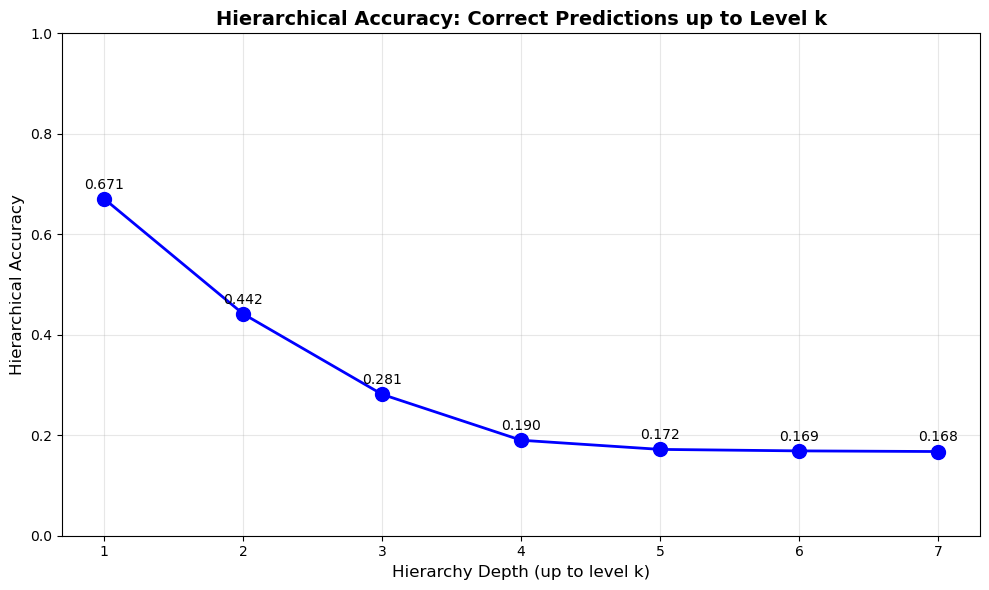

In [19]:
def calculate_hierarchical_metrics(true_labels, predictions, label_encoders):
    """
    Calculate hierarchical precision, recall, and F1.
    Considers hierarchical consistency - predictions should follow valid taxonomy paths.
    """
    # Convert predictions and labels to paths
    num_samples = len(true_labels[0])
    
    # Calculate hierarchical accuracy (correct at all levels up to k)
    hierarchical_accuracy = []
    for k in range(1, 8):
        correct = 0
        for i in range(num_samples):
            # Check if first k levels are all correct
            if all(predictions[level][i] == true_labels[level][i] for level in range(k)):
                correct += 1
        hierarchical_accuracy.append(correct / num_samples)
    
    # Calculate path consistency (whether predictions form valid taxonomy paths)
    valid_path_count = 0
    for i in range(num_samples):
        # Reconstruct predicted path
        pred_path = tuple([label_encoders[level]['id_to_label'][predictions[level][i]] 
                          for level in range(7)])
        
        # Check if path exists in valid paths
        if pred_path in valid_paths_set:
            valid_path_count += 1
    
    path_consistency = valid_path_count / num_samples
    
    return {
        'hierarchical_accuracy': hierarchical_accuracy,
        'path_consistency': path_consistency
    }

# Calculate hierarchical metrics
print("Calculating hierarchical metrics...")
hier_metrics = calculate_hierarchical_metrics(final_true_labels, final_predictions, label_encoders)

print("\nHierarchical Accuracy (correct up to level k):")
for k, acc in enumerate(hier_metrics['hierarchical_accuracy'], 1):
    print(f"  Up to Level {k}: {acc:.4f}")

print(f"\nPath Consistency (valid taxonomy paths): {hier_metrics['path_consistency']:.4f}")

# Visualize hierarchical accuracy
plt.figure(figsize=(10, 6))
levels_k = list(range(1, 8))
plt.plot(levels_k, hier_metrics['hierarchical_accuracy'], 'b-o', linewidth=2, markersize=10)
plt.xlabel('Hierarchy Depth (up to level k)', fontsize=12)
plt.ylabel('Hierarchical Accuracy', fontsize=12)
plt.title('Hierarchical Accuracy: Correct Predictions up to Level k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(levels_k)
plt.ylim([0, 1])
for i, acc in enumerate(hier_metrics['hierarchical_accuracy']):
    plt.text(i+1, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'hierarchical_accuracy.png'), dpi=300, bbox_inches='tight')
plt.show()

## Saving Artifacts

This section saves the **tokenizer, label encoders, and evaluation results**to the output directory for future use or deployment.

In [20]:
# Save tokenizer
tokenizer.save_pretrained(os.path.join(CONFIG['output_dir'], 'tokenizer'))
print(f"Tokenizer saved to {CONFIG['output_dir']}/tokenizer")

# Save label encoders
with open(os.path.join(CONFIG['output_dir'], 'label_encoders.json'), 'w') as f:
    # Convert to JSON-serializable format
    encoders_json = []
    for encoder in label_encoders:
        encoders_json.append({
            'label_to_id': encoder['label_to_id'],
            'id_to_label': {str(k): v for k, v in encoder['id_to_label'].items()},
            'num_labels': encoder['num_labels']
        })
    json.dump(encoders_json, f, indent=2)
print(f"Label encoders saved to {CONFIG['output_dir']}/label_encoders.json")

# Save evaluation results
results = {
    'final_avg_f1': float(final_avg_f1),
    'f1_by_level': {f'level_{k}': float(v) for k, v in final_f1_scores.items()},
    'accuracies_by_level': {f'level_{k}': float(accuracy_score(final_true_labels[k], final_predictions[k])) 
                            for k in range(7)},
    'hierarchical_accuracy': [float(x) for x in hier_metrics['hierarchical_accuracy']],
    'path_consistency': float(hier_metrics['path_consistency']),
    'training_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'eval_f1': [float(x) for x in history['eval_f1']]
    },
    'config': CONFIG
}

with open(os.path.join(CONFIG['output_dir'], 'evaluation_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f"Evaluation results saved to {CONFIG['output_dir']}/evaluation_results.json")

print("\nAll artifacts saved successfully!")

Tokenizer saved to ./outputs/tokenizer
Label encoders saved to ./outputs/label_encoders.json
Evaluation results saved to ./outputs/evaluation_results.json

All artifacts saved successfully!


## Inference: Predict Hierarchical Classification for a New Paper

This section defines a function to **predict hierarchical labels** for a new research paper using the trained model.

In [21]:
def predict_classification(title, abstract, model, tokenizer, label_encoders, device='cuda'):
    """
    Predict hierarchical classification for a new research paper.
    
    Args:
        title: Paper title
        abstract: Paper abstract
        model: Trained model
        tokenizer: Tokenizer
        label_encoders: Label encoders for each level
        device: Device to run inference on
    
    Returns:
        Dictionary with predicted labels for each level and full path
    """
    model.eval()
    
    # Prepare text
    text = f"{clean_text(title)} [SEP] {clean_text(abstract)}"
    
    # Tokenize
    encoding = tokenizer(
        text,
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(input_ids, attention_mask)
    
    # Get predictions for each level
    predictions = {}
    predicted_path = []
    
    for level in range(7):
        pred_id = torch.argmax(logits[level], dim=-1).item()
        pred_label = label_encoders[level]['id_to_label'][pred_id]
        predictions[f'level_{level}'] = pred_label
        predicted_path.append(pred_label)
    
    predictions['full_path'] = ' > '.join(predicted_path)
    
    return predictions

# Example usage
print("Testing inference on a sample paper...")
sample_paper = test_processed[0]

# Extract title and abstract from original text
text_parts = sample_paper['text'].split('[SEP]')
sample_title = text_parts[0].strip() if len(text_parts) > 0 else ""
sample_abstract = text_parts[1].strip() if len(text_parts) > 1 else ""

predicted = predict_classification(
    sample_title,
    sample_abstract,
    model,
    tokenizer,
    label_encoders,
    device
)

print("\nSample Paper:")
print(f"Title: {sample_title[:100]}...")
print(f"Abstract: {sample_abstract[:200]}...")
print(f"\nPredicted Classification Path:")
print(predicted['full_path'])
print(f"\nActual Classification Path:")
print(sample_paper['original_path'])

Testing inference on a sample paper...

Sample Paper:
Title: information security in medical robotics: a survey on the level of training, awareness and use of th...
Abstract: cybersecurity is becoming an increasingly important aspect to investigate for the adoption and use of care robots, in term of both patients safety, and the availability, integrity and privacy of their...

Predicted Classification Path:
Natural Science > Computer and Information Science > Computer Security and Privacy > Privacy Technology > Human-Robot Interaction > Gesture Recognition > Gesture Recognition

Actual Classification Path:
Natural Science > Computer and Information Science > Computer Security and Privacy > Privacy Technology > Differential Privacy


## Training and Evaluation Visualizations

This section creates a **multi-panel figure** summarizing training progress, level-wise F1 scores, accuracy, and a confusion matrix.


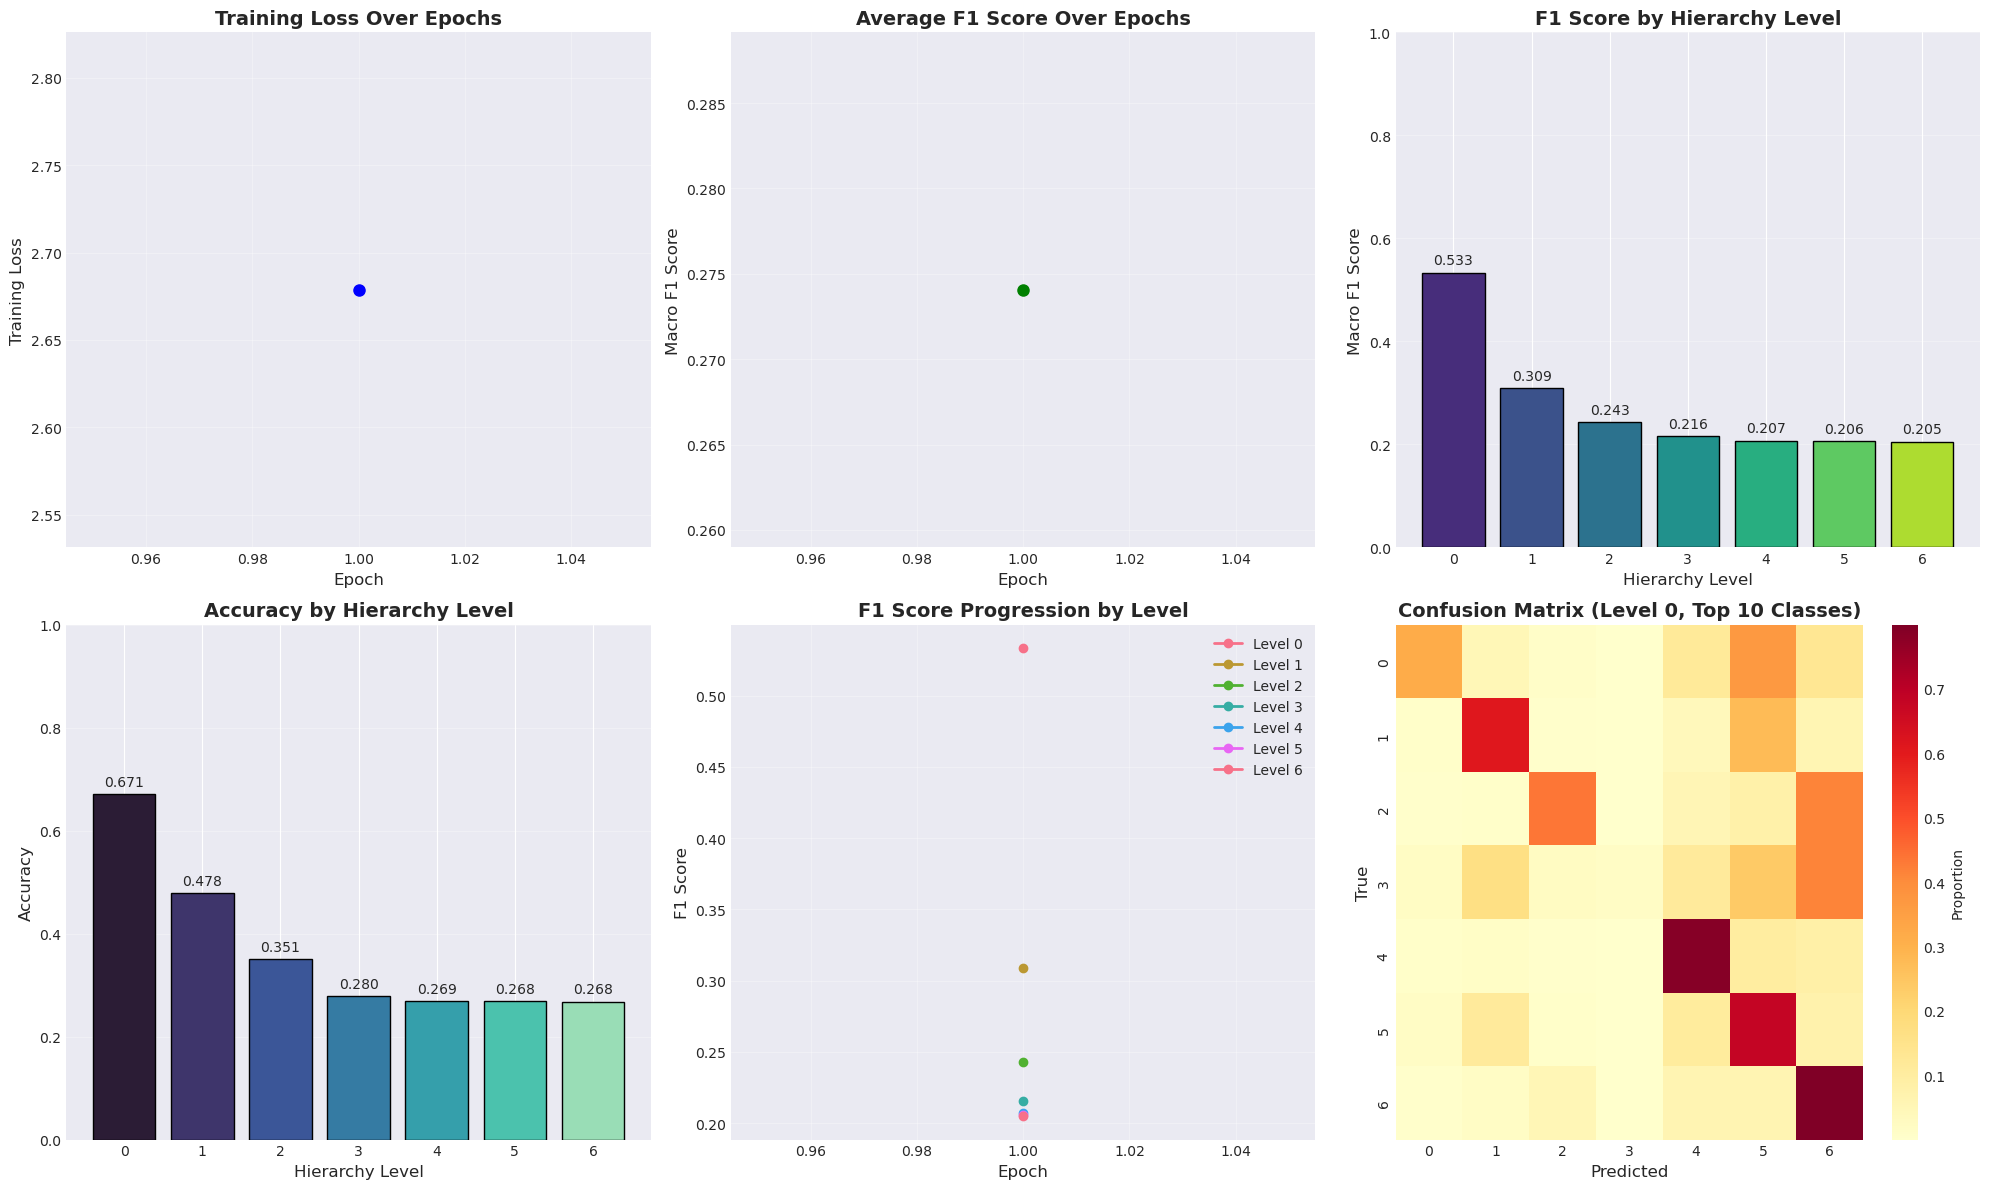

Visualization saved to ./outputs/training_results.png


In [23]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. Training Loss Curve
ax1 = plt.subplot(2, 3, 1)
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. F1 Score Over Epochs
ax2 = plt.subplot(2, 3, 2)
ax2.plot(epochs, history['eval_f1'], 'g-o', linewidth=2, markersize=8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Macro F1 Score', fontsize=12)
ax2.set_title('Average F1 Score Over Epochs', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. F1 Score by Level (Bar Plot)
ax3 = plt.subplot(2, 3, 3)
levels = list(range(7))
final_f1_values = [final_f1_scores[i] for i in levels]
bars = ax3.bar(levels, final_f1_values, color=sns.color_palette("viridis", 7), edgecolor='black')
ax3.set_xlabel('Hierarchy Level', fontsize=12)
ax3.set_ylabel('Macro F1 Score', fontsize=12)
ax3.set_title('F1 Score by Hierarchy Level', fontsize=14, fontweight='bold')
ax3.set_xticks(levels)
ax3.set_ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars, final_f1_values)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Accuracy by Level
ax4 = plt.subplot(2, 3, 4)
accuracies = [accuracy_score(final_true_labels[i], final_predictions[i]) for i in range(7)]
bars = ax4.bar(levels, accuracies, color=sns.color_palette("mako", 7), edgecolor='black')
ax4.set_xlabel('Hierarchy Level', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Accuracy by Hierarchy Level', fontsize=14, fontweight='bold')
ax4.set_xticks(levels)
ax4.set_ylim([0, 1])
for i, (bar, val) in enumerate(zip(bars, accuracies)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Level-wise F1 Progression
ax5 = plt.subplot(2, 3, 5)
for level in range(7):
    if history['level_f1'][level]:
        ax5.plot(range(1, len(history['level_f1'][level]) + 1), 
                history['level_f1'][level], 
                marker='o', label=f'Level {level}', linewidth=2)
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('F1 Score', fontsize=12)
ax5.set_title('F1 Score Progression by Level', fontsize=14, fontweight='bold')
ax5.legend(loc='best', fontsize=10)
ax5.grid(True, alpha=0.3)

# 6. Confusion Matrix for Level 0 (sample)
ax6 = plt.subplot(2, 3, 6)
cm = confusion_matrix(final_true_labels[0], final_predictions[0])
# Normalize for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized[:10, :10], annot=False, fmt='.2f', cmap='YlOrRd', 
            ax=ax6, cbar_kws={'label': 'Proportion'})
ax6.set_title('Confusion Matrix (Level 0, Top 10 Classes)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Predicted', fontsize=12)
ax6.set_ylabel('True', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_results.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved to {CONFIG['output_dir']}/training_results.png")

# BASELINE EVALUATION - Pre-Fine-Tuning 

In [ ]:


print("Creating BASELINE model (random classification heads)")
baseline_model = HierarchicalClassifier(CONFIG['model_name'], label_encoders, use_lora=True)
baseline_model = baseline_model.to(device)  # GPU!
baseline_model.eval()

print(" Evaluating BASELINE on test set...")
baseline_avg_f1, baseline_f1_scores, _, _ = evaluate(baseline_model, test_loader)

print("\n" + "="*50)
print("BASELINE RESULTS (Random Heads)")
print("="*50)
print(f"Average F1 Score: {baseline_avg_f1:.4f}")
print("F1 Scores by Level:")
for level, f1 in baseline_f1_scores.items():
    print(f"  Level {level}: {f1:.4f}")

# Save baseline
baseline_results = {'avg_f1': float(baseline_avg_f1), 'levels': {str(k): float(v) for k,v in baseline_f1_scores.items()}}
with open(os.path.join(CONFIG['output_dir'], 'baseline_f1.json'), 'w') as f:
    import json
    json.dump(baseline_results, f, indent=2)
    
print(f"\n Saved to {CONFIG['output_dir']}/baseline_f1.json")
print(" BASELINE COMPLETE! Expected ~0.05-0.10 F1")


🔄 Creating BASELINE model (random classification heads)
LoRA applied to backbone:
trainable params: 294,912 || all params: 110,213,376 || trainable%: 0.2676
📊 Evaluating BASELINE on test set...


Evaluating:   0%|          | 0/15006 [00:00<?, ?it/s]


BASELINE RESULTS (Random Heads)
Average F1 Score: 0.0105
F1 Scores by Level:
  Level 0: 0.0701
  Level 1: 0.0021
  Level 2: 0.0006
  Level 3: 0.0001
  Level 4: 0.0002
  Level 5: 0.0001
  Level 6: 0.0001

💾 Saved to ./outputs/baseline_f1.json
✅ BASELINE COMPLETE! Expected ~0.05-0.10 F1


# ***Summary***

# Hierarchical Text Classification Pipeline 
1. Configuration & Verification

Loaded configuration from CONFIG dictionary (model name, directories, batch size, etc.).

Verified that all required paths exist:

Taxonomy file

Training data

Test data

Created necessary directories for checkpoints and outputs.

# 2. Taxonomy Handling

Loaded hierarchical taxonomy from JSON.

Extracted all possible paths recursively.

Padded paths to 7 levels to ensure consistency.

Built a set of valid 7-level paths for later hierarchical consistency checks.

# 3. Label Encoding

Created label encoders for each of the 7 hierarchy levels:

label_to_id maps labels to numeric IDs.

id_to_label maps IDs back to labels.

Displayed example mappings for the first few labels.
# 4. Data Loading

Loaded all JSON files from training and test directories.

Extracted articles and filtered valid entries.

Displayed the total number of samples loaded.

# 5. Preprocessing

Cleaned text: removed HTML tags, extra whitespace.

Parsed classification paths into hierarchical labels.

Combined title and abstract into a single text input.

Padded labels to 7 levels.

Preprocessed both training and test datasets and displayed sample outputs.
# 6. Tokenization & Dataset

Initialized tokenizer from the chosen pretrained model.

Created a custom HierarchicalDataset:

Tokenizes text to max length.

Converts labels to numeric IDs.

Created DataLoader objects for training and test sets.

Verified batch shapes.
# 7. Hierarchical Classifier

Built a 7-head classifier on top of a transformer backbone.

Used LoRA (Low-Rank Adaptation) for parameter-efficient fine-tuning.

Output: logits for each hierarchy level.

Counted total and trainable parameters.
# 8. Training Setup

Loss function: CrossEntropyLoss per level.

Optimizer: AdamW.

Scheduler: Linear warmup.

Checkpointing functions:

Save model, optimizer, scheduler, best F1 score.

Load latest checkpoint to resume training.

Loaded checkpoint if available to resume training.
# 9. Main Training Loop

For each epoch:

Trained on training batches.

Evaluated on test set.

Calculated average F1 and level-wise F1 scores.

Saved checkpoints and updated best model.

Implemented early stopping based on F1 improvement.

Tracked training history (loss and F1 scores).
# 10. Checkpoint Loading & Final Evaluation

Loaded a specific checkpoint for final evaluation.

Evaluated model on test set:

Average F1 score.

F1 score per level.

Verified predictions against the taxonomy.

# 11. Hierarchical Metrics

Calculated hierarchical accuracy: proportion of samples correct up to level k.

Calculated path consistency: proportion of predicted paths that are valid according to the taxonomy.

Visualized hierarchical accuracy across levels.
# 12. Artifact Saving

Saved tokenizer for future inference.

Saved label encoders as JSON.

Saved evaluation results:

Final F1, level-wise F1 and accuracy.

Hierarchical metrics.

Training history.

All artifacts stored in the output directory.
# 13. Inference

Created a predict_classification function for new papers.

Input: title and abstract.

Output: predicted labels for each of the 7 levels and full classification path.

Verified prediction on a sample test paper against actual labels.
# 4. Visualization

Generated multi-panel figure including:

Training loss curve.

Average F1 over epochs.

F1 score by hierarchy level.

Accuracy by hierarchy level.

Level-wise F1 progression over epochs.

Confusion matrix for Level 0 (top 10 classes).

Saved the figure as training_results.png.

